In [ ]:
import numpy as np
import pandas as pd

PROJECT_DIR = '/Users/rosakwak/Desktop/DATA3888/DATA3888G08'
DATA_PATH = PROJECT_DIR + '/optiver_aggregated.csv'

LIQUIDITY_PROFILE_PATH = '/Users/rosakwak/Desktop/DATA3888/DATA3888G08/har_rv_stock_liquidity_profile.csv'


def label_bucket_liquidity(frame, bas_q33, bas_q66, act_q33, act_q66):
    conditions = [
        (frame['bas'] <= bas_q33) & (frame['log_activity'] >= act_q66),
        (frame['bas'] >= bas_q66) & (frame['log_activity'] <= act_q33),
    ]
    choices = ['liquid', 'illiquid']
    frame['bucket_liquidity'] = np.select(conditions, choices, default='mixed')
    return frame


def stock_regime(row):
    if row['liquid_pct'] >= 0.40:
        return 'liquid'
    if row['illiquid_pct'] >= 0.40:
        return 'illiquid'
    return 'mixed'


liq_df = pd.read_csv(
    DATA_PATH,
    usecols=['stock_id', 'time_id', 'time_bucket', 'BidAskSpread_mean', 'RV']
)
liq_df = liq_df.rename(columns={'BidAskSpread_mean': 'bas', 'RV': 'rv'})
liq_df['time_bucket'] = liq_df['time_bucket'].astype(int)

# Use buckets 1-16 only, matching the HAR-RV training window.
liq_df = liq_df[liq_df['time_bucket'].between(1, 16)].copy()

# Code.txt uses WAP-based activity. This HAR-RV aggregated file does not have WAP_mean,
# so inverse spread is the available liquidity/activity proxy.
liq_df['inv_spread'] = 1.0 / (liq_df['bas'] + 1e-6)
liq_df['log_activity'] = np.log1p(liq_df['inv_spread'])

bas_q33 = liq_df['bas'].quantile(0.33)
bas_q66 = liq_df['bas'].quantile(0.66)
act_q33 = liq_df['log_activity'].quantile(0.33)
act_q66 = liq_df['log_activity'].quantile(0.66)

liq_df = label_bucket_liquidity(liq_df, bas_q33, bas_q66, act_q33, act_q66)

stock_liquidity_profile = (
    liq_df.groupby('stock_id')
    .agg(
        median_bas=('bas', 'median'),
        mean_bas=('bas', 'mean'),
        median_log_activity=('log_activity', 'median'),
        median_rv=('rv', 'median'),
        mean_rv=('rv', 'mean'),
        rv_std=('rv', 'std'),
        liquid_pct=('bucket_liquidity', lambda x: (x == 'liquid').mean()),
        illiquid_pct=('bucket_liquidity', lambda x: (x == 'illiquid').mean()),
        mixed_pct=('bucket_liquidity', lambda x: (x == 'mixed').mean()),
        n_buckets=('rv', 'count'),
    )
    .reset_index()
)

stock_liquidity_profile['stock_regime'] = stock_liquidity_profile.apply(stock_regime, axis=1)
stock_liquidity_profile['recommended_model'] = np.where(
    stock_liquidity_profile['stock_regime'] == 'liquid',
    'EGARCH-X',
    'WLS / HAR-RV'
)

# Put most liquid stocks at the top.
stock_liquidity_profile = stock_liquidity_profile.sort_values(
    ['liquid_pct', 'median_bas'],
    ascending=[False, True]
).reset_index(drop=True)

stock_liquidity_profile.to_csv(LIQUIDITY_PROFILE_PATH, index=False)

top10_liquid_stocks = (
    stock_liquidity_profile[stock_liquidity_profile['stock_regime'] == 'liquid']
    .sort_values('liquid_pct', ascending=False)
    .head(10)
)

top10_illiquid_stocks = (
    stock_liquidity_profile[stock_liquidity_profile['stock_regime'] == 'illiquid']
    .sort_values('illiquid_pct', ascending=False)
    .head(10)
)

top10_liquid_path = '/Users/rosakwak/Desktop/DATA3888/DATA3888G08/har_rv_top10_liquid_stocks.csv'
top10_illiquid_path = '/Users/rosakwak/Desktop/DATA3888/DATA3888G08/har_rv_top10_illiquid_stocks.csv'

top10_liquid_stocks.to_csv(top10_liquid_path, index=False)
top10_illiquid_stocks.to_csv(top10_illiquid_path, index=False)

print('Saved:', LIQUIDITY_PROFILE_PATH)
print('Saved top 10 liquid stocks:', top10_liquid_path)
print('Saved top 10 illiquid stocks:', top10_illiquid_path)
print('Global BAS q33/q66:', bas_q33, bas_q66)
print('Global log_activity q33/q66:', act_q33, act_q66)
print(stock_liquidity_profile['stock_regime'].value_counts())

print('\n10 MOST LIQUID stocks')
display_cols = [
    'stock_id', 'liquid_pct', 'illiquid_pct', 'mixed_pct',
    'median_bas', 'median_log_activity', 'stock_regime', 'recommended_model'
]
print(top10_liquid_stocks[display_cols].to_string(index=False))

print('\n10 MOST ILLIQUID stocks')
print(top10_illiquid_stocks[display_cols].to_string(index=False))

top10_liquid_stocks[display_cols], top10_illiquid_stocks[display_cols]


In [ ]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = '/Users/rosakwak/Desktop/DATA3888/DATA3888G08'
OUTPUT_DIR = os.path.join(PROJECT_DIR, 'har_rv_outputs')

# Get forecast results safely. If the model cell has not run in this session,
# load the saved per-stock forecast CSVs from har_rv_outputs.
if 'results' in globals():
    plot_results = results.copy()
elif 'forecast_df' in globals():
    plot_results = forecast_df.copy()
else:
    forecast_files = glob.glob(os.path.join(OUTPUT_DIR, 'stock_*', 'rosa_har_rv_forecasts.csv'))
    if not forecast_files:
        raise NameError(
            'No results found yet. Run the main HAR-RV model cell first so it creates forecast CSVs.'
        )
    frames = []
    for path in forecast_files:
        frame = pd.read_csv(path)
        stock_folder = os.path.basename(os.path.dirname(path))
        frame['stock_id'] = int(stock_folder.replace('stock_', ''))
        frames.append(frame)
    plot_results = pd.concat(frames, ignore_index=True)

# Support both naming styles used in this notebook.
actual_col = 'target_RV' if 'target_RV' in plot_results.columns else 'actual_RV'
pred_col = 'pred_RV'

plt.figure(figsize=(8, 6))
plt.scatter(plot_results[actual_col], plot_results[pred_col], alpha=0.6, edgecolors='w', s=50)
plt.plot(
    [plot_results[actual_col].min(), plot_results[actual_col].max()],
    [plot_results[actual_col].min(), plot_results[actual_col].max()],
    'r--', linewidth=2, label='Perfect Prediction'
)
plt.xlabel('Actual RV')
plt.ylabel('Predicted RV')
plt.title('Predicted vs Actual RV')
plt.legend()
plt.show()


In [ ]:
"""
M4 — Phase 3: HAR-RV Model
Rosa's deliverable
"""

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore")

PROJECT_DIR = "/Users/rosakwak/Desktop/DATA3888/DATA3888G08"
os.chdir(PROJECT_DIR)

INPUT_CSV = os.path.join(PROJECT_DIR, "optiver_aggregated.csv")
OUTPUT_DIR = os.path.join(PROJECT_DIR, "har_rv_outputs")

N_TRAIN = 16
N_VAL = 4
N_STOCKS = 10

os.makedirs(OUTPUT_DIR, exist_ok=True)


def qlike(pred, actual):
    if pred <= 0 or actual < 0 or not np.isfinite(pred):
        return np.nan
    pred = max(pred, 1e-10)
    return (np.log(pred) + actual / pred)**2


def build_har_features(rv_series):
    rv = np.asarray(rv_series, dtype=np.float64)
    rv_d = rv[-1]
    rv_w = rv[-min(5, len(rv)):].mean()
    rv_m = rv[-min(16, len(rv)):].mean()
    return rv_d, rv_w, rv_m


def fit_har_rv(vol_train_dict, vol_val_dict, time_ids):
    """Fit one HAR-RV model per stock using buckets 1-16, then predict buckets 17-20.

    No rolling-window validation and no cross-validation are used here.
    The model learns from all available first-8-minute bucket transitions:
        feature at bucket t = [RV_lag1, RV_mean5, RV_mean16]
        target at bucket t  = RV_t

    For evaluation, each time_id starts with its actual buckets 1-16, then the
    model recursively predicts buckets 17-20. We compare the mean predicted
    RV over those 4 buckets with the actual mean RV over buckets 17-20.
    """
    eval_records = []
    forecast_records = []

    X_fit, y_fit = [], []

    for tid in time_ids:
        rv_train = vol_train_dict[tid]["RV"].values

        if len(rv_train) < 6:
            continue

        for t in range(1, len(rv_train)):
            window = rv_train[:t]
            d = window[-1]
            w = window[-min(5, len(window)):].mean()
            m = window[-min(16, len(window)):].mean()
            X_fit.append([d, w, m])
            y_fit.append(rv_train[t])

    if len(X_fit) < 3:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    X_fit = np.array(X_fit)
    y_fit = np.array(y_fit)

    model = LinearRegression(fit_intercept=True)
    model.fit(X_fit, y_fit)
    train_r2 = model.score(X_fit, y_fit)

    param_df = pd.DataFrame([{
        "intercept": model.intercept_,
        "beta_daily": model.coef_[0],
        "beta_weekly": model.coef_[1],
        "beta_monthly": model.coef_[2],
        "r2": train_r2,
        "n_training_rows": len(y_fit)
    }])

    for tid in time_ids:
        rv_train = vol_train_dict[tid]["RV"].values
        rv_val = vol_val_dict[tid]["RV"].values

        if len(rv_train) < 6 or len(rv_val) == 0:
            continue

        history = list(rv_train.astype(float))
        bucket_preds = []

        for _ in range(len(rv_val)):
            rv_d, rv_w, rv_m = build_har_features(history)
            X_pred = np.array([[rv_d, rv_w, rv_m]])
            pred = float(model.predict(X_pred)[0])
            pred = max(pred, 1e-8)
            bucket_preds.append(pred)
            history.append(pred)

        pred_rv = float(np.mean(bucket_preds))
        actual = float(rv_val.mean())

        q = qlike(pred_rv, actual)
        mse = (actual - pred_rv) ** 2

        eval_records.append({
            "time_id": tid,
            "pred_RV": pred_rv,
            "actual_RV": actual,
            "QLIKE": q,
            "MSE": mse,
            "n_train_buckets": len(rv_train),
            "n_prediction_buckets": len(rv_val)
        })

        forecast_records.append({
            "time_id": tid,
            "pred_RV": pred_rv,
            "actual_RV": actual,
            "pred_bucket_17": bucket_preds[0] if len(bucket_preds) > 0 else np.nan,
            "pred_bucket_18": bucket_preds[1] if len(bucket_preds) > 1 else np.nan,
            "pred_bucket_19": bucket_preds[2] if len(bucket_preds) > 2 else np.nan,
            "pred_bucket_20": bucket_preds[3] if len(bucket_preds) > 3 else np.nan,
            "actual_bucket_17": rv_val[0] if len(rv_val) > 0 else np.nan,
            "actual_bucket_18": rv_val[1] if len(rv_val) > 1 else np.nan,
            "actual_bucket_19": rv_val[2] if len(rv_val) > 2 else np.nan,
            "actual_bucket_20": rv_val[3] if len(rv_val) > 3 else np.nan,
            "rv_d": rv_train[-1],
            "rv_w": rv_train[-min(5, len(rv_train)):].mean(),
            "rv_m": rv_train[-min(16, len(rv_train)):].mean()
        })

    return (
        pd.DataFrame(eval_records),
        param_df,
        pd.DataFrame(forecast_records)
    )


print("Loading data ...")
df = pd.read_csv(INPUT_CSV)

required_cols = ["stock_id", "time_id", "time_bucket", "RV"]
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

print(f"{df['stock_id'].nunique()} stocks found.")

if os.path.exists(os.path.join(PROJECT_DIR, "har_rv_top10_illiquid_stocks.csv")):
    illiquid_file = os.path.join(PROJECT_DIR, "har_rv_top10_illiquid_stocks.csv")
    illiquid_df = pd.read_csv(illiquid_file)

    if "stock_id" in illiquid_df.columns:
        illiquid_selected = illiquid_df["stock_id"].dropna().astype(int).unique().tolist()
    else:
        illiquid_selected = illiquid_df.iloc[:, 0].dropna().astype(int).unique().tolist()

    illiquid_selected = illiquid_selected[:N_STOCKS]
else:
    illiquid_selected = sorted(df["stock_id"].unique())[:N_STOCKS]

print(f"\nSelected {len(illiquid_selected)} illiquid stocks: {illiquid_selected}")
print("HAR-RV runs on these stocks.")


all_har_summary = []

for STOCK_ID in illiquid_selected:
    print(f"\n{'=' * 65}")
    print(f"HAR-RV: Stock {STOCK_ID} ({illiquid_selected.index(STOCK_ID) + 1}/{len(illiquid_selected)})")
    print(f"{'=' * 65}")

    stock_out = os.path.join(OUTPUT_DIR, f"stock_{STOCK_ID}")
    os.makedirs(stock_out, exist_ok=True)

    stock_df = df[df["stock_id"] == STOCK_ID].copy()
    stock_df = stock_df.sort_values(["time_id", "time_bucket"]).reset_index(drop=True)

    vol_train, vol_val = {}, {}

    for tid in sorted(stock_df["time_id"].unique()):
        buckets = (
            stock_df[stock_df["time_id"] == tid]
            .sort_values("time_bucket")
            .reset_index(drop=True)
        )

        if len(buckets) < N_TRAIN + N_VAL:
            continue

        vol_train[tid] = buckets.iloc[:N_TRAIN].copy()
        vol_val[tid] = buckets.iloc[N_TRAIN:N_TRAIN + N_VAL].copy()

    time_IDs = sorted(vol_train.keys())

    if not time_IDs:
        print("No complete time_ids — skipping.")
        continue

    print(f"{len(time_IDs)} complete time_ids selected")

    eval_df, param_df, forecast_df = fit_har_rv(vol_train, vol_val, time_IDs)

    if eval_df.empty:
        print("No valid HAR-RV forecasts — skipping.")
        continue

    eval_df.to_csv(os.path.join(stock_out, "rosa_har_rv_eval_results.csv"), index=False)
    param_df.to_csv(os.path.join(stock_out, "rosa_har_rv_params.csv"), index=False)
    forecast_df.to_csv(os.path.join(stock_out, "rosa_har_rv_forecasts.csv"), index=False)

    per_tid = eval_df.groupby("time_id")[["QLIKE", "MSE"]].mean()
    med_q = per_tid["QLIKE"].median()
    med_mse = per_tid["MSE"].median()

    print(f"n time_ids evaluated: {len(per_tid)}")
    print(f"Median QLIKE: {med_q:.4f}")
    print(f"Median MSE: {med_mse:.2e}")
    print(f"Mean beta_d: {param_df['beta_daily'].mean():.4f}")
    print(f"Mean beta_w: {param_df['beta_weekly'].mean():.4f}")
    print(f"Mean beta_m: {param_df['beta_monthly'].mean():.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    fig.patch.set_facecolor("white")
    fig.suptitle(f"HAR-RV — Stock {STOCK_ID} (illiquid)", fontsize=11, fontweight="500")

    C = "#D85A30"

    for ax in axes:
        ax.set_facecolor("white")
        for sp in ax.spines.values():
            sp.set_color("#D3D1C7")
            sp.set_linewidth(0.6)

    axes[0].scatter(
        forecast_df["actual_RV"],
        forecast_df["pred_RV"],
        alpha=0.45,
        s=14,
        color=C,
        edgecolors="none"
    )

    lim = max(forecast_df["actual_RV"].max(), forecast_df["pred_RV"].max()) * 1.06
    axes[0].plot([0, lim], [0, lim], "k--", linewidth=0.9, alpha=0.6)
    axes[0].set_xlabel("Actual RV", fontsize=9)
    axes[0].set_ylabel("Predicted RV", fontsize=9)
    axes[0].set_title("Predicted vs Actual RV", fontsize=10)
    axes[0].grid(color="#D3D1C7", linewidth=0.4, linestyle="--")
    axes[0].set_axisbelow(True)

    qlike_sorted = per_tid["QLIKE"].sort_values().values
    axes[1].bar(range(len(qlike_sorted)), qlike_sorted, color=C, alpha=0.7, width=0.85)
    axes[1].axhline(med_q, color="black", linestyle="--", linewidth=0.9, label=f"Median {med_q:.3f}")
    axes[1].set_xlabel("time_id sorted by QLIKE", fontsize=9)
    axes[1].set_ylabel("QLIKE", fontsize=9)
    axes[1].set_title("QLIKE per time_id", fontsize=10)
    axes[1].legend(fontsize=8)
    axes[1].grid(axis="y", color="#D3D1C7", linewidth=0.4, linestyle="--")
    axes[1].set_axisbelow(True)

    plt.tight_layout()
    plt.savefig(os.path.join(stock_out, "rosa_har_rv_summary.png"), dpi=150, bbox_inches="tight")
    plt.close()

    all_har_summary.append({
        "stock_id": STOCK_ID,
        "liquidity_regime": "illiquid",
        "n_time_ids": len(per_tid),
        "median_QLIKE": med_q,
        "median_MSE": med_mse,
        "mean_beta_d": param_df["beta_daily"].mean(),
        "mean_beta_w": param_df["beta_weekly"].mean(),
        "mean_beta_m": param_df["beta_monthly"].mean(),
        "mean_r2": param_df["r2"].mean()
    })


if all_har_summary:
    summary_df = pd.DataFrame(all_har_summary).sort_values("stock_id")
    summary_df.to_csv(os.path.join(OUTPUT_DIR, "all_stocks_har_rv_summary.csv"), index=False)

    print("\nSaved: all_stocks_har_rv_summary.csv")
    print(f"\n{'=' * 60}")
    print(f"HAR-RV across {len(all_har_summary)} illiquid stocks:")
    print(f"Overall median QLIKE: {summary_df['median_QLIKE'].median():.4f}")
    print(f"Overall median MSE: {summary_df['median_MSE'].median():.2e}")
    print(f"{'=' * 60}")

    C = "#D85A30"
    SPINE = "#D3D1C7"

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.patch.set_facecolor("white")
    fig.suptitle("HAR-RV — Performance Across All Illiquid Stocks", fontsize=12, fontweight="500")

    ranked = summary_df.sort_values("median_QLIKE").reset_index(drop=True)
    labels = [f"Stock {int(r['stock_id'])}" for _, r in ranked.iterrows()]

    ax = axes[0]
    ax.set_facecolor("white")
    ax.barh(labels, ranked["median_QLIKE"], color=C, alpha=0.75, height=0.65)
    ax.axvline(
        ranked["median_QLIKE"].median(),
        color="#444441",
        linestyle="--",
        linewidth=0.9,
        label=f"Median {ranked['median_QLIKE'].median():.3f}"
    )

    for sp in ax.spines.values():
        sp.set_color(SPINE)
        sp.set_linewidth(0.6)

    ax.tick_params(labelsize=8, color=SPINE)
    ax.set_xlabel("Median QLIKE lower is better", fontsize=9)
    ax.set_title("QLIKE by Stock", fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(axis="x", color=SPINE, linewidth=0.4, linestyle="--")
    ax.set_axisbelow(True)

    ax2 = axes[1]
    ax2.set_facecolor("white")

    x = np.arange(len(ranked))
    w = 0.25

    ax2.bar(x - w, ranked["mean_beta_d"], width=w, label="β daily", color="#D85A30", alpha=0.8)
    ax2.bar(x, ranked["mean_beta_w"], width=w, label="β weekly", color="#F0997B", alpha=0.8)
    ax2.bar(
        x + w,
        ranked["mean_beta_m"],
        width=w,
        label="β monthly",
        color="#FAECE7",
        alpha=0.9,
        edgecolor="#D85A30",
        linewidth=0.6
    )

    ax2.axhline(0, color=SPINE, linewidth=0.7)
    ax2.set_xticks(x)
    ax2.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)

    for sp in ax2.spines.values():
        sp.set_color(SPINE)
        sp.set_linewidth(0.6)

    ax2.tick_params(labelsize=8, color=SPINE)
    ax2.set_ylabel("Coefficient value", fontsize=9)
    ax2.set_title("HAR Coefficients by Stock", fontsize=10)
    ax2.legend(fontsize=8)
    ax2.grid(axis="y", color=SPINE, linewidth=0.4, linestyle="--")
    ax2.set_axisbelow(True)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "rosa_01_har_rv_performance.png"), dpi=150, bbox_inches="tight")
    plt.close()

    print("Saved: rosa_01_har_rv_performance.png")

    all_forecast_frames = []

    for sid in illiquid_selected:
        p = os.path.join(OUTPUT_DIR, f"stock_{sid}", "rosa_har_rv_forecasts.csv")

        if os.path.exists(p):
            df_ = pd.read_csv(p)
            df_["stock_id"] = sid
            all_forecast_frames.append(df_)

    if all_forecast_frames:
        all_fc = pd.concat(all_forecast_frames, ignore_index=True)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        fig.patch.set_facecolor("white")
        fig.suptitle("HAR-RV — Forecast Quality All Illiquid Stocks Combined", fontsize=12, fontweight="500")

        ax = axes[0]
        ax.set_facecolor("white")
        ax.scatter(
            all_fc["actual_RV"],
            all_fc["pred_RV"],
            alpha=0.25,
            s=8,
            color=C,
            edgecolors="none"
        )

        lim = np.percentile(np.concatenate([all_fc["actual_RV"], all_fc["pred_RV"]]), 99) * 1.1
        ax.plot([0, lim], [0, lim], "k--", linewidth=0.9, alpha=0.6, label="Perfect forecast")
        ax.set_xlim(0, lim)
        ax.set_ylim(0, lim)

        for sp in ax.spines.values():
            sp.set_color(SPINE)
            sp.set_linewidth(0.6)

        ax.set_xlabel("Actual RV", fontsize=9)
        ax.set_ylabel("Predicted RV", fontsize=9)
        ax.set_title("Predicted vs Actual", fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(color=SPINE, linewidth=0.3, linestyle="--")
        ax.set_axisbelow(True)

        residuals = all_fc["pred_RV"] - all_fc["actual_RV"]

        ax2 = axes[1]
        ax2.set_facecolor("white")
        ax2.hist(residuals.clip(-0.01, 0.01), bins=40, color=C, alpha=0.75, edgecolor="white")
        ax2.axvline(0, color="#444441", linewidth=0.9, linestyle="--", label="Zero error")
        ax2.axvline(
            residuals.mean(),
            color="#1D9E75",
            linewidth=0.9,
            linestyle="--",
            label=f"Mean {residuals.mean():.5f}"
        )

        for sp in ax2.spines.values():
            sp.set_color(SPINE)
            sp.set_linewidth(0.6)

        ax2.set_xlabel("Forecast error pred minus actual", fontsize=9)
        ax2.set_ylabel("Count", fontsize=9)
        ax2.set_title("Residual Distribution", fontsize=10)
        ax2.legend(fontsize=8)
        ax2.grid(axis="y", color=SPINE, linewidth=0.3, linestyle="--")
        ax2.set_axisbelow(True)

        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, "rosa_02_har_rv_residuals.png"), dpi=150, bbox_inches="tight")
        plt.close()

        print("Saved: rosa_02_har_rv_residuals.png") 

print("\n✓ rosa_har_rv.py complete.")


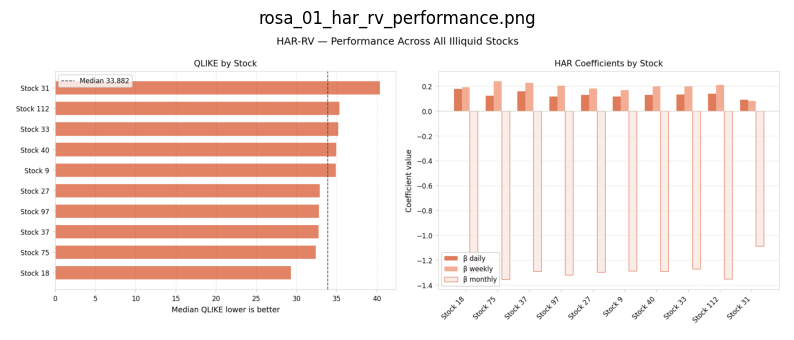

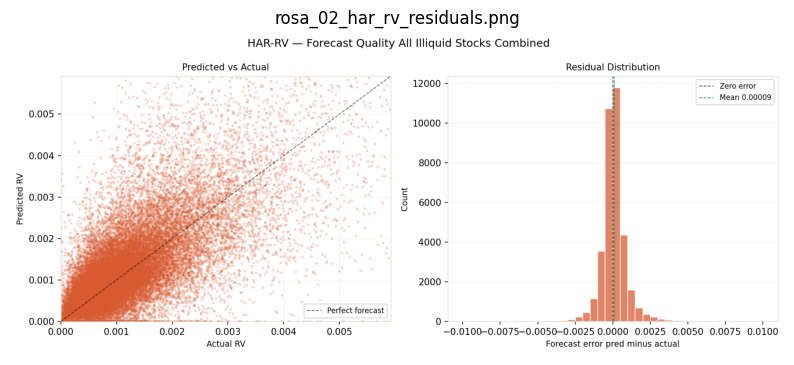

In [4]:
# Display saved HAR-RV summary plots directly in the notebook.
# If this notebook is run interactively, the following code will show the PNGs.
import os
import matplotlib.pyplot as plt

plot_files = [
    os.path.join(OUTPUT_DIR, "rosa_01_har_rv_performance.png"),
    os.path.join(OUTPUT_DIR, "rosa_02_har_rv_residuals.png")
]

for plot_path in plot_files:
    if os.path.exists(plot_path):
        img = plt.imread(plot_path)
        plt.figure(figsize=(10, 6))
        plt.imshow(img)
        plt.axis('off')
        plt.title(os.path.basename(plot_path))
        plt.show()
    else:
        print(f"Plot not found: {plot_path}")